# Pricing Actuarial con GLM y Scoring Comercial con Machine Learning

> **Objetivo:** Construir un modelo de pricing actuarial completo para seguros de automóviles utilizando el enfoque clásico de la industria: GLM Poisson para frecuencia y GLM Gamma para severidad. Como extensión práctica, se incorpora un score de riesgo relativo basado en XGBoost que permite segmentación comercial sin alterar la suficiencia de prima a nivel de cartera.
>
> **Dataset:** freMTPL2 — mercado francés de seguro de responsabilidad civil obligatoria de automóviles (*Motor Third-Party Liability*).

## 0. Librerías e Inicialización

In [53]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# ── Datos ─────────────────────────────────────────────────────────────────────
from sklearn.datasets import fetch_openml

# ── Preprocesamiento y evaluación ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# ── Modelos GLM ───────────────────────────────────────────────────────────────
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ── Scoring comercial ─────────────────────────────────────────────────────────
from xgboost import XGBRegressor

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
PALETA = {"glm": "#1565C0", "xgb": "#E65100", "real": "#2E7D32", "neutro": "#546E7A"}

RANDOM_STATE = 42
TEST_SIZE    = 0.20

## 1. Introducción

### El modelo de pricing actuarial

El estándar de la industria aseguradora para calcular la **prima pura** de una póliza es:

$$\text{Prima Pura} = \text{Frecuencia} \times \text{Severidad}$$

donde:
- **Frecuencia** = número esperado de siniestros por unidad de exposición
- **Severidad** = importe esperado por siniestro

Este enfoque en dos etapas permite modelar por separado dos fenómenos con distribuciones muy distintas:

| Componente | Variable | Distribución | Modelo |  
|---|---|---|---|
| Frecuencia | `ClaimNb` (conteos) | Poisson | GLM Poisson con offset de exposición |
| Severidad | `ClaimAmount` (montos) | Gamma | GLM Gamma con link log |

### ¿Por qué GLM y no Machine Learning para el pricing?

Los GLMs son el estándar de la industria por razones concretas:

- **Distribuciones correctas:** el GLM Poisson respeta la naturaleza discreta y no negativa de los conteos; el GLM Gamma respeta que los montos son continuos, positivos y de cola derecha.
- **Exposición como offset:** el GLM maneja nativamente que las pólizas tienen distinto tiempo de vigencia (fracción de año asegurado), lo que los modelos de ML no incorporan de forma natural.
- **Interpretabilidad regulatoria:** los coeficientes son directamente interpretables y auditables por organismos reguladores.
- **Parsimonia:** con pocos predictores y un proceso generador bien especificado, el GLM captura toda la señal disponible sin sobreajustar.

### El rol del Machine Learning en pricing

El ML no reemplaza al GLM en este contexto — lo complementa.

- El **GLM** define la prima actuarialmente justa (modelo regulatorio)
- El **ML** construye un *score de riesgo relativo* que permite diferenciar pólizas dentro de un mismo segmento tarifario (capa comercial)

Este proyecto implementa exactamente ese flujo.

## 2. Preparación de los Datos

In [54]:
def cargar_datos() -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Carga los datasets freMTPL2freq y freMTPL2sev desde OpenML.

    Returns
    -------
    freq : pd.DataFrame
        Dataset de frecuencia (una fila por póliza).
    sev : pd.DataFrame
        Dataset de severidad (una fila por siniestro individual).
    """
    print("Cargando freMTPL2freq (frecuencia)...")
    freq = fetch_openml(data_id=41214, as_frame=True).frame

    print("Cargando freMTPL2sev (severidad)...")
    sev  = fetch_openml(data_id=41215, as_frame=True).frame

    print(f"\n  freq : {freq.shape[0]:,} pólizas, {freq.shape[1]} variables")
    print(f"  sev  : {sev.shape[0]:,} siniestros, {sev.shape[1]} variables")
    return freq, sev


def construir_dataset_severidad(freq: pd.DataFrame, sev: pd.DataFrame) -> pd.DataFrame:
    """
    Enriquece el dataset de severidad con variables de la póliza
    (VehAge, DrivAge, BonusMalus) mediante un left join por IDpol.

    Se eliminan las filas sin match en freq (~36 siniestros, < 0.2% del total),
    que generarían NaN en las features y romperían la predicción del GLM Gamma.

    Parameters
    ----------
    freq : pd.DataFrame
        Dataset de frecuencia (debe contener IDpol, VehAge, DrivAge, BonusMalus).
    sev : pd.DataFrame
        Dataset de severidad (debe contener IDpol, ClaimAmount).

    Returns
    -------
    sev_enriquecido : pd.DataFrame
        Dataset de severidad con variables de póliza, sin filas con NaN.
    """
    # IDpol es float64 en freq (OpenML lo carga con posibles NaNs) e int64 en sev.
    # Sin el casteo explícito el merge puede fallar silenciosamente por
    # incompatibilidad de tipos. Se normaliza a int64 en ambos antes del join.
    freq_join = freq[["IDpol", "VehAge", "DrivAge", "BonusMalus"]].copy()
    freq_join["IDpol"] = freq_join["IDpol"].astype("int64")
    sev_join = sev.copy()
    sev_join["IDpol"] = sev_join["IDpol"].astype("int64")

    sev_enriquecido = sev_join.merge(
        freq_join,
        on="IDpol",
        how="left"
    )

    n_antes = len(sev_enriquecido)
    sev_enriquecido = sev_enriquecido.dropna(
        subset=["VehAge", "DrivAge", "BonusMalus"]
    ).reset_index(drop=True)
    n_eliminados = n_antes - len(sev_enriquecido)

    if n_eliminados > 0:
        print(f"  [INFO] Se eliminaron {n_eliminados} siniestros sin póliza asociada "
              f"({n_eliminados/n_antes*100:.2f}% del total).")

    return sev_enriquecido


# ── Carga y enriquecimiento ────────────────────────────────────────────────────
freq_raw, sev_raw      = cargar_datos()
sev_enriquecido        = construir_dataset_severidad(freq_raw, sev_raw)

print("\nPrimeras filas del dataset de frecuencia:")
freq_raw.head()

Cargando freMTPL2freq (frecuencia)...
Cargando freMTPL2sev (severidad)...

  freq : 678,013 pólizas, 12 variables
  sev  : 26,639 siniestros, 2 variables
  [INFO] Se eliminaron 195 siniestros sin póliza asociada (0.73% del total).

Primeras filas del dataset de frecuencia:


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72


In [55]:
def codificar_features_ml(freq: pd.DataFrame) -> pd.DataFrame:
    """
    Codifica las variables categóricas del dataset de frecuencia para su uso
    en modelos de árbol (XGBoost). Se aplica Label Encoding ordinal, suficiente
    para árboles que no asumen distancia métrica entre categorías.

    Variables codificadas: Area, VehBrand, VehGas, Region.

    Parameters
    ----------
    freq : pd.DataFrame
        Dataset original de frecuencia.

    Returns
    -------
    freq_cod : pd.DataFrame
        Dataset con variables categóricas codificadas numéricamente.
    """
    freq_cod = freq.copy()
    for col in ["Area", "VehBrand", "VehGas", "Region"]:
        if col in freq_cod.columns:
            freq_cod[col] = freq_cod[col].astype("category").cat.codes
    return freq_cod


def preparar_split_frecuencia(
    freq: pd.DataFrame,
    features: list[str],
    target: str = "ClaimNb",
    exposure_col: str = "Exposure",
    test_size: float = TEST_SIZE,
    random_state: int = RANDOM_STATE
) -> dict:
    """
    Genera el train/test split para los modelos de frecuencia.
    El mismo split se reutiliza en todos los modelos para garantizar
    comparabilidad estricta.

    Parameters
    ----------
    freq         : DataFrame de frecuencia (con encoding aplicado si corresponde).
    features     : Variables explicativas.
    target       : Variable objetivo (ClaimNb).
    exposure_col : Columna de exposición (fracción de año asegurado).
    test_size    : Proporción del set de test.
    random_state : Semilla de aleatoriedad.

    Returns
    -------
    dict con X_train, X_test, y_train, y_test, exposure_train, exposure_test.
    """
    X = freq[features + [exposure_col]]
    y = freq[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    return {
        "X_train"       : X_train[features],
        "X_test"        : X_test[features],
        "y_train"       : y_train,
        "y_test"        : y_test,
        "exposure_train": X_train[exposure_col],
        "exposure_test" : X_test[exposure_col],
    }


# ── Features ──────────────────────────────────────────────────────────────────
# El GLM usa variables numéricas directamente y categóricas via C() en la
# fórmula de smf.glm — dummies con categoría de referencia, que es el
# tratamiento estadísticamente correcto para un modelo lineal generalizado.
FEATURES_GLM_NUM  = ["VehAge", "DrivAge", "BonusMalus", "VehPower", "Density"]
FEATURES_GLM_CAT  = ["VehGas", "Region"]
FEATURES_GLM      = FEATURES_GLM_NUM + FEATURES_GLM_CAT

# El XGBoost del scoring incorpora todas las variables disponibles
# para maximizar la capacidad de discriminación de riesgo.
FEATURES_ML   = ["VehAge", "DrivAge", "BonusMalus", "VehPower", "Density",
                 "Area", "VehBrand", "VehGas", "Region"]

FEATURES_SEV  = ["VehAge", "DrivAge", "BonusMalus"]

# Fórmula del GLM Poisson — se usa en smf.glm y en patsy para predicción
FORMULA_GLM_POISSON = (
    "ClaimNb ~ VehAge + DrivAge + BonusMalus + VehPower + Density "
    "+ C(VehGas) + C(Region)"
)

# ── Encoding y splits ─────────────────────────────────────────────────────────
freq_codificado = codificar_features_ml(freq_raw)

# Split base (índices compartidos por todos los modelos)
split_ml = preparar_split_frecuencia(
    freq=freq_codificado, features=FEATURES_ML
)

# Split GLM — mismos índices, todas las features del GLM desde freq_raw
# (smf.glm maneja las categóricas internamente via la fórmula)
split_glm = {
    "X_train"       : freq_raw.loc[split_ml["X_train"].index, FEATURES_GLM],
    "X_test"        : freq_raw.loc[split_ml["X_test"].index,  FEATURES_GLM],
    "y_train"       : split_ml["y_train"],
    "y_test"        : split_ml["y_test"],
    "exposure_train": split_ml["exposure_train"],
    "exposure_test" : split_ml["exposure_test"],
}

print(f"Train : {len(split_glm['X_train']):,} pólizas")
print(f"Test  : {len(split_glm['X_test']):,} pólizas")
print(f"\nDistribución de ClaimNb en train:")
print(split_glm["y_train"].value_counts().sort_index().head(6).to_string())

Train : 542,410 pólizas
Test  : 135,603 pólizas

Distribución de ClaimNb en train:
ClaimNb
0    515196
1     25705
2      1429
3        66
4         6
5         2


## 3. Modelo de Frecuencia — GLM Poisson

Se modela `ClaimNb` (número de siniestros por póliza) con un GLM de familia Poisson y link log.

La exposición (`Exposure`) representa la fracción de año durante la cual la póliza estuvo vigente.
Incorporarla como **offset** — en lugar de como predictor — es la forma actuarialmente correcta:
le indica al modelo que una póliza con 0.5 años de vigencia tiene, *a priori*, la mitad de probabilidad
de siniestros que una póliza equivalente con 1 año completo.

$$\log(\mathbb{E}[\text{ClaimNb}]) = \log(\text{Exposure}) + \beta_0 + \beta_1 \cdot \text{VehAge} + \beta_2 \cdot \text{DrivAge} + \beta_3 \cdot \text{BonusMalus} + \beta_4 \cdot \text{VehPower} + \beta_5 \cdot \text{Density} + \sum_k \gamma_k \cdot \mathbb{1}[\text{VehGas}_k] + \sum_j \delta_j \cdot \mathbb{1}[\text{Region}_j]$$

=== Métricas globales del GLM Poisson ===
  AIC            : 229394.96
  BIC (Deviance) : -6987546.63
  Deviance       : 173944.59
  Null Deviance  : 179539.27
  % Deviance exp.: 3.12%
  Grados libertad: 542,382

=== Coeficientes — Variables numéricas y VehGas ===
                           Coef.  Std.Err.          z     P>|z|    [0.025    0.975]
C(VehGas)[T.'Regular']  0.073485  0.012085   6.080847  0.000000  0.049800  0.097171
VehAge                 -0.043881  0.001209 -36.297455  0.000000 -0.046251 -0.041512
DrivAge                 0.006989  0.000436  16.012860  0.000000  0.006134  0.007844
BonusMalus              0.022976  0.000339  67.685739  0.000000  0.022311  0.023641
VehPower                0.017527  0.002926   5.990930  0.000000  0.011793  0.023261
Density                 0.000006  0.000002   3.676473  0.000236  0.000003  0.000009


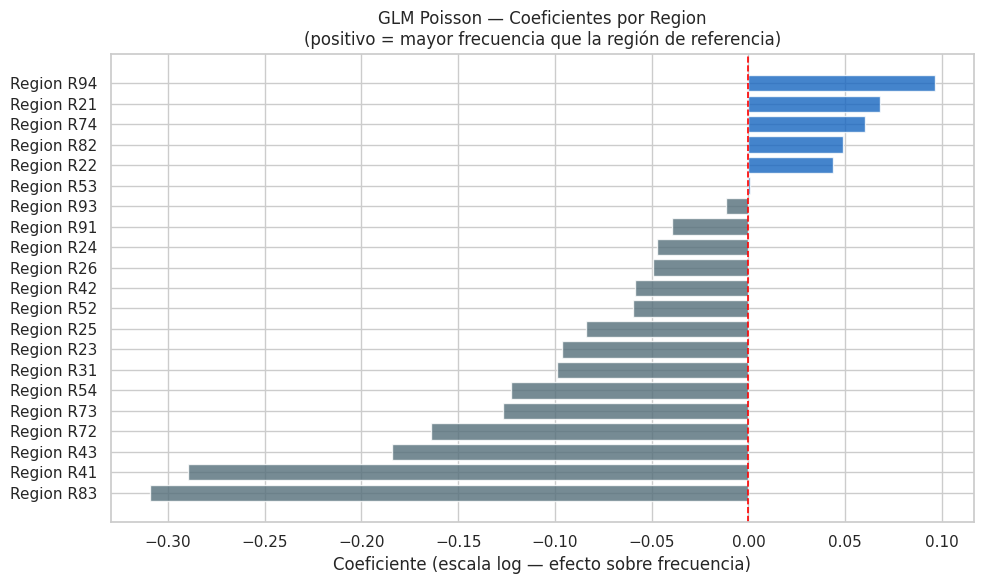

In [56]:
def ajustar_glm_poisson(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    formula: str,
    exposure_train: pd.Series,
    exposure_test: pd.Series
) -> tuple:
    """
    Ajusta un GLM Poisson con offset de exposición usando la API de fórmulas
    de statsmodels (smf.glm), que permite incorporar variables categóricas
    via C(Variable) — dummies con categoría de referencia automática.

    La exposición se incorpora como log(Exposure) en el término offset,
    lo que es equivalente a restringir su coeficiente a 1.0 — la forma
    actuarialmente correcta de escalar predicciones al tiempo asegurado.

    Parameters
    ----------
    train_df       : DataFrame de entrenamiento con todas las features y ClaimNb.
    test_df        : DataFrame de test con todas las features.
    formula        : Fórmula del modelo (e.g. 'ClaimNb ~ VehAge + C(VehGas)').
    exposure_train : Fracción de año asegurado en train.
    exposure_test  : Fracción de año asegurado en test.

    Returns
    -------
    modelo : Modelo ajustado (GLMResultsWrapper).
    preds  : Predicciones en test (ClaimNb esperado).
    """
    modelo = smf.glm(
        formula=formula,
        data=train_df,
        family=sm.families.Poisson(),
        offset=np.log(exposure_train)
    ).fit()

    preds = modelo.predict(test_df, offset=np.log(exposure_test))
    return modelo, preds


# ── Armar DataFrames de train/test con ClaimNb para smf.glm ──────────────────
glm_train_df = split_glm["X_train"].copy()
glm_train_df["ClaimNb"] = split_glm["y_train"].values

glm_test_df  = split_glm["X_test"].copy()

glm_poisson, preds_glm_poisson = ajustar_glm_poisson(
    train_df       = glm_train_df,
    test_df        = glm_test_df,
    formula        = FORMULA_GLM_POISSON,
    exposure_train = split_glm["exposure_train"],
    exposure_test  = split_glm["exposure_test"]
)

# ── Opción B: métricas globales + coeficientes numéricos + gráfico de Region ──
# El summary completo incluye ~22 dummies de Region que saturan el output.
# Se muestran por separado: métricas globales del modelo, coeficientes de las
# variables numéricas, y un gráfico de los coeficientes de Region ordenados.

print("=== Métricas globales del GLM Poisson ===")
print(f"  AIC            : {glm_poisson.aic:.2f}")
print(f"  BIC (Deviance) : {glm_poisson.bic:.2f}")
print(f"  Deviance       : {glm_poisson.deviance:.2f}")
print(f"  Null Deviance  : {glm_poisson.null_deviance:.2f}")
print(f"  % Deviance exp.: {(1 - glm_poisson.deviance / glm_poisson.null_deviance)*100:.2f}%")
print(f"  Grados libertad: {glm_poisson.df_resid:,}")

# Coeficientes de variables numéricas y VehGas
vars_mostrar = ["const", "VehAge", "DrivAge", "BonusMalus", "VehPower", "Density"]
coefs_num = glm_poisson.summary2().tables[1]
mask_num = coefs_num.index.str.startswith(tuple(vars_mostrar)) | coefs_num.index.str.startswith("C(VehGas)")
print("\n=== Coeficientes — Variables numéricas y VehGas ===")
print(coefs_num[mask_num].round(6).to_string())

# Gráfico de coeficientes de Region
coefs_region = coefs_num[coefs_num.index.str.startswith("C(Region)")].copy()
coefs_region.index = coefs_region.index.str.replace("C(Region)[T.", "Region ", regex=False).str.replace("]", "", regex=False)
coefs_region = coefs_region.sort_values("Coef.")

fig, ax = plt.subplots(figsize=(10, 6))
colores_region = [PALETA["glm"] if v > 0 else PALETA["neutro"] for v in coefs_region["Coef."]]
ax.barh(coefs_region.index, coefs_region["Coef."], color=colores_region, alpha=0.8)
ax.axvline(0, color="red", linestyle="--", linewidth=1.2)
ax.set_xlabel("Coeficiente (escala log — efecto sobre frecuencia)")
ax.set_title("GLM Poisson — Coeficientes por Region\n(positivo = mayor frecuencia que la región de referencia)")
plt.tight_layout()
plt.show()

## 4. Modelo de Severidad — GLM Gamma

Se modela `ClaimAmount` (importe individual por siniestro) con un GLM de familia Gamma y link log.

La distribución Gamma es la elección apropiada para montos de siniestros:
- Variable **continua y estrictamente positiva**
- Distribución **asimétrica hacia la derecha** (cola de siniestros graves)
- **Varianza proporcional al cuadrado de la media** — comportamiento típico de costos de siniestros

El dataset de severidad contiene una fila por **siniestro individual**, no por póliza.
Por eso tiene su propio train/test split, independiente del de frecuencia.

In [57]:
def preparar_split_severidad(
    sev: pd.DataFrame,
    features: list[str],
    target: str = "ClaimAmount",
    test_size: float = TEST_SIZE,
    random_state: int = RANDOM_STATE
) -> dict:
    """
    Genera el train/test split para el modelo de severidad.

    Parameters
    ----------
    sev          : Dataset de severidad enriquecido con variables de póliza.
    features     : Variables explicativas.
    target       : Variable objetivo (ClaimAmount).
    test_size    : Proporción del set de test.
    random_state : Semilla de aleatoriedad.

    Returns
    -------
    dict con X_train, X_test, y_train, y_test.
    """
    X = sev[features]
    y = sev[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    return {
        "X_train": X_train,
        "X_test" : X_test,
        "y_train": y_train,
        "y_test" : y_test,
    }


def ajustar_glm_gamma(sev_train: pd.DataFrame) -> tuple:
    """
    Ajusta un GLM Gamma con link log para modelar severidad de siniestros.

    Parameters
    ----------
    sev_train : DataFrame de entrenamiento con ClaimAmount, VehAge, DrivAge, BonusMalus.

    Returns
    -------
    modelo : Modelo ajustado (GLMResultsWrapper).
    """
    modelo = smf.glm(
        formula="ClaimAmount ~ VehAge + DrivAge + BonusMalus",
        data=sev_train,
        family=sm.families.Gamma(sm.families.links.log())
    ).fit()
    return modelo


# ── Split de severidad ────────────────────────────────────────────────────────
split_sev = preparar_split_severidad(
    sev=sev_enriquecido, features=FEATURES_SEV
)

# ── Entrenamiento ─────────────────────────────────────────────────────────────
# Se arma el DataFrame de train completo para la API de fórmulas de statsmodels
sev_train_df = split_sev["X_train"].copy()
sev_train_df["ClaimAmount"] = split_sev["y_train"]

glm_gamma = ajustar_glm_gamma(sev_train_df)
print(glm_gamma.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            ClaimAmount   No. Observations:                21155
Model:                            GLM   Df Residuals:                    21151
Model Family:                   Gamma   Df Model:                            3
Link Function:                    log   Scale:                          97.816
Method:                          IRLS   Log-Likelihood:            -2.4302e+05
Date:                Tue, 10 Mar 2026   Deviance:                       37155.
Time:                        16:31:44   Pearson chi2:                 2.07e+06
No. Iterations:                    26   Pseudo R-squ. (CS):          0.0006083
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.2182      0.427     16.896      0.0

In [58]:
def poisson_deviance(y_real: pd.Series, y_pred: np.ndarray) -> float:
    """
    Calcula la Poisson Deviance media entre valores reales y predichos.

    Es la métrica actuarial estándar para evaluar modelos de frecuencia.
    A diferencia del RMSE, penaliza correctamente errores en distribuciones
    de conteo con muchos ceros y no asume varianza constante.

    Fórmula: 2 × Σ [ y × log(y / ŷ) − (y − ŷ) ] / n
    Convención: cuando y = 0, el término y × log(y/ŷ) = 0.

    Returns
    -------
    float : Poisson Deviance media (menor es mejor; 0 = ajuste perfecto).
    """
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-10, None)
    log_term = np.where(y_real > 0, y_real * np.log(y_real / y_pred), 0.0)
    return 2 * np.sum(log_term - (y_real - y_pred)) / len(y_real)


def evaluar_modelo_frecuencia(nombre: str, y_real: pd.Series, y_pred: np.ndarray) -> dict:
    """
    Calcula las métricas de evaluación para un modelo de frecuencia.

    Métricas:
    - Poisson Deviance : métrica actuarial estándar para conteos.
    - MAE              : error absoluto medio en escala original.
    - R²               : proporción de varianza explicada.
    """
    return {
        "Modelo"           : nombre,
        "Poisson Deviance" : poisson_deviance(y_real, y_pred),
        "MAE"              : mean_absolute_error(y_real, y_pred),
        "R²"               : r2_score(y_real, y_pred),
    }


def gamma_deviance(y_real: pd.Series, y_pred: np.ndarray) -> float:
    """
    Calcula la Gamma Deviance media entre valores reales y predichos.

    Es la métrica actuarial estándar para modelos de severidad.
    Análogo a la Poisson Deviance pero para la distribución Gamma:
    penaliza correctamente errores en variables continuas positivas
    con varianza proporcional al cuadrado de la media.

    Fórmula: 2 × Σ [ log(ŷ/y) + (y - ŷ)/ŷ ] / n

    Returns
    -------
    float : Gamma Deviance media (menor es mejor; 0 = ajuste perfecto).
    """
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-10, None)
    return 2 * np.mean(np.log(y_pred / y_real) + (y_real - y_pred) / y_pred)


def evaluar_modelo_severidad(nombre: str, y_real: pd.Series, y_pred: np.ndarray) -> dict:
    """
    Calcula las métricas de evaluación para un modelo de severidad.

    Métricas:
    - Gamma Deviance : métrica actuarial estándar para variables continuas
                       positivas con distribución Gamma. Análogo a Poisson
                       Deviance para frecuencia.
    - MAE            : error absoluto medio en euros.
    - R²             : proporción de varianza explicada.
    """
    return {
        "Modelo"         : nombre,
        "Gamma Deviance" : gamma_deviance(y_real, y_pred),
        "MAE"            : mean_absolute_error(y_real, y_pred),
        "R²"             : r2_score(y_real, y_pred),
    }


# ── Evaluación frecuencia ─────────────────────────────────────────────────────
metricas_freq = pd.DataFrame([
    evaluar_modelo_frecuencia("GLM Poisson", split_glm["y_test"], preds_glm_poisson),
]).set_index("Modelo").round(6)

print("=== Métricas — Frecuencia (ClaimNb) ===")
print(metricas_freq.to_string())

# ── Evaluación severidad ──────────────────────────────────────────────────────
preds_glm_gamma_test = glm_gamma.predict(split_sev["X_test"])

metricas_sev = pd.DataFrame([
    evaluar_modelo_severidad("GLM Gamma", split_sev["y_test"], preds_glm_gamma_test),
]).set_index("Modelo").round(4)

print("\n=== Métricas — Severidad (ClaimAmount) ===")
print(metricas_sev.to_string())

=== Métricas — Frecuencia (ClaimNb) ===
             Poisson Deviance       MAE        R²
Modelo                                           
GLM Poisson          0.321777  0.098848  0.008904

Nota: Poisson Deviance es la métrica correcta para variables de conteo.

=== Métricas — Severidad (ClaimAmount) ===
           Gamma Deviance      MAE      R²
Modelo                                    
GLM Gamma          1.4988  2070.22  0.0004

Nota: Gamma Deviance es la métrica correcta para variables continuas positivas con distribución Gamma.


## 5. Visualización de los Modelos GLM

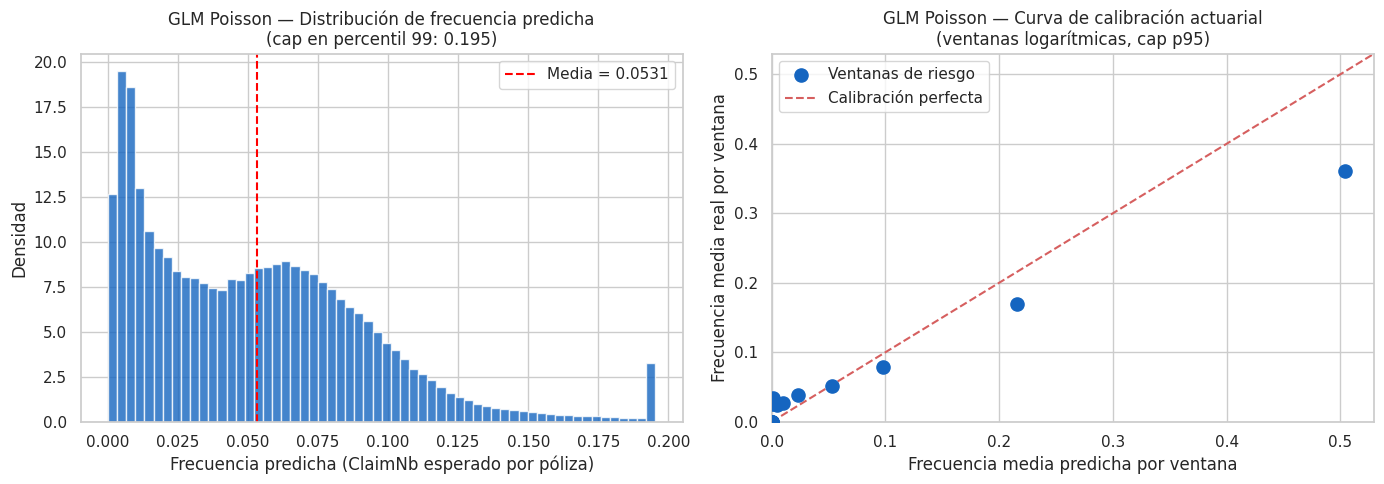

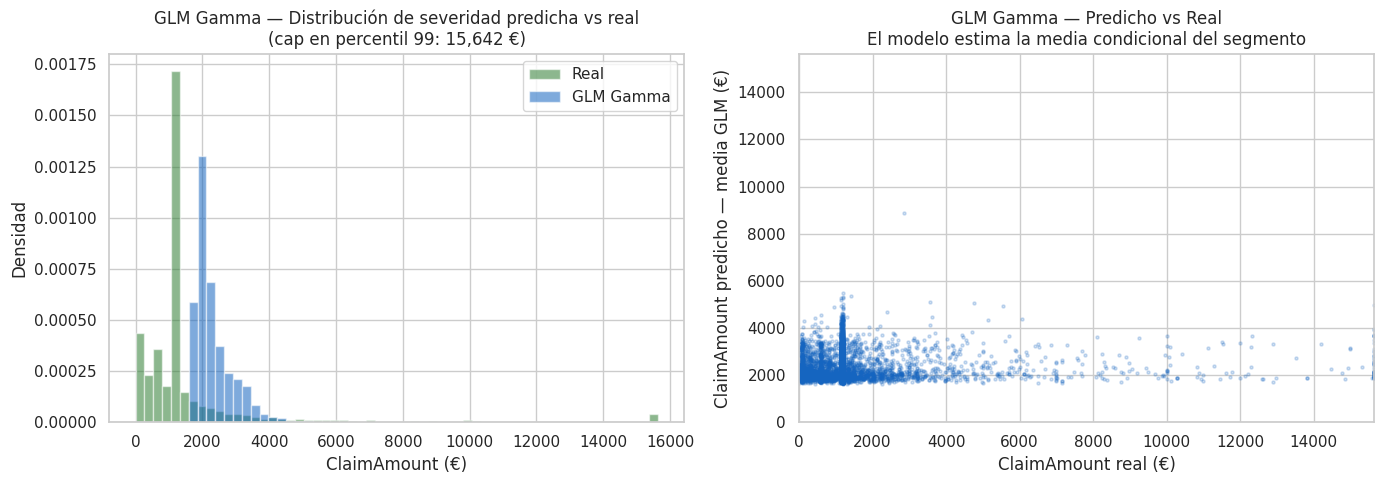

In [59]:
def graficar_glm_frecuencia(
    y_test: pd.Series,
    preds: np.ndarray
) -> None:
    """
    Genera dos visualizaciones diagnósticas para el GLM Poisson de frecuencia.

    Panel 1 — Distribución de la frecuencia predicha por el GLM.
        Histograma de ClaimNb esperado por póliza. Muestra cómo el modelo
        distribuye el riesgo en la cartera: mayoría de pólizas con frecuencia
        muy baja y cola derecha de perfiles de mayor riesgo.

    Panel 2 — Curva de calibración actuarial (deciles de frecuencia predicha).
        Las pólizas se ordenan por frecuencia predicha y se agrupan en 10 deciles.
        Para cada decil se compara la frecuencia media predicha vs la real observada.
        Un modelo bien calibrado produce puntos sobre la diagonal: a mayor riesgo
        predicho, mayor siniestralidad observada.

    Parameters
    ----------
    y_test : ClaimNb real en test.
    preds  : Predicciones del GLM Poisson (ClaimNb esperado por póliza).
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Panel 1: Distribución de frecuencia predicha por el GLM ────────────────
    # Muestra cómo el GLM distribuye el riesgo entre las pólizas del test set.
    # La mayoría de las pólizas tiene frecuencia esperada muy baja (cerca de 0),
    # con una cola derecha que corresponde a los perfiles de mayor riesgo.
    # La línea vertical marca la media de la cartera.
    ax = axes[0]
    cap_freq = float(np.percentile(preds, 99))
    ax.hist(
        np.clip(preds, 0, cap_freq),
        bins=60, color=PALETA["glm"], alpha=0.8, density=True
    )
    ax.axvline(preds.mean(), color="red", linestyle="--", linewidth=1.5,
               label=f"Media = {preds.mean():.4f}")
    ax.set_xlabel("Frecuencia predicha (ClaimNb esperado por póliza)")
    ax.set_ylabel("Densidad")
    ax.set_title("GLM Poisson — Distribución de frecuencia predicha\n"                 f"(cap en percentil 99: {cap_freq:.3f})")
    ax.legend()

    # ── Panel 2: Curva de calibración actuarial (ventanas logarítmicas) ────────
    # Las predicciones del GLM Poisson están fuertemente concentradas cerca de 0
    # (distribución asimétrica). Con deciles de igual tamaño los grupos quedarían
    # con predicciones medias muy similares y el gráfico sería poco informativo.
    # Se usan ventanas en escala log para distribuir mejor el rango de riesgo:
    # la diferencia entre 0.01 y 0.02 es tan relevante como entre 0.10 y 0.20.
    ax2 = axes[1]

    calibracion = pd.DataFrame({"real": y_test.values, "pred": preds})

    # Ventanas logarítmicas sobre el rango de predicciones
    pred_min = calibracion["pred"][calibracion["pred"] > 0].min()
    pred_max = calibracion["pred"].max()
    cortes_log = np.unique(np.concatenate([
        [0],
        np.exp(np.linspace(np.log(pred_min), np.log(pred_max), 15))
    ]))
    calibracion["ventana"] = pd.cut(
        calibracion["pred"], bins=cortes_log, labels=False, include_lowest=True
    )
    resumen = calibracion.groupby("ventana")[["real", "pred"]].mean().dropna()

    # Se limita al percentil 95 de las predicciones para evitar que los outliers
    # de BonusMalus muy alto distorsionen la escala y aplasten los puntos centrales.
    cap_calib = float(np.percentile(resumen["pred"], 95))
    resumen_plot = resumen[resumen["pred"] <= cap_calib]

    lim_min = min(resumen_plot["pred"].min(), resumen_plot["real"].min()) * 0.95
    lim_max = max(resumen_plot["pred"].max(), resumen_plot["real"].max()) * 1.05
    ax2.scatter(
        resumen_plot["pred"], resumen_plot["real"],
        color=PALETA["glm"], s=90, zorder=3, label="Ventanas de riesgo"
    )
    ax2.plot([lim_min, lim_max], [lim_min, lim_max],
             "r--", linewidth=1.5, label="Calibración perfecta")
    ax2.set_xlim(lim_min, lim_max)
    ax2.set_ylim(lim_min, lim_max)
    ax2.set_xlabel("Frecuencia media predicha por ventana")
    ax2.set_ylabel("Frecuencia media real por ventana")
    ax2.set_title("GLM Poisson — Curva de calibración actuarial\n(ventanas logarítmicas, cap p95)")
    ax2.legend()

    plt.tight_layout()
    plt.show()


def graficar_glm_severidad(
    y_test: pd.Series,
    preds: np.ndarray
) -> None:
    """
    Genera dos visualizaciones diagnósticas para el GLM Gamma de severidad.

    Panel 1 — Histogramas superpuestos en escala original (cap percentil 99).
        Muestra que el GLM Gamma predice la media condicional del segmento,
        produciendo una distribución más concentrada que los valores reales
        individuales. Comportamiento correcto y esperado para un GLM.

    Panel 2 — Scatter de ClaimAmount predicho vs real.
        La nube de puntos se concentra en una banda horizontal: el modelo
        predice valores similares (la media del segmento) para siniestros
        reales muy distintos. Esto refleja que el GLM captura tendencias
        centrales por segmento, no la variabilidad individual de cada siniestro.
        Ejes limitados al percentil 99 para una mejor visualización.

    Parameters
    ----------
    y_test : ClaimAmount real en test (importe por siniestro).
    preds  : Predicciones del GLM Gamma (media condicional por siniestro).
    """
    cap = float(np.percentile(y_test, 99))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Panel 1: Histogramas en escala original ───────────────────────────────
    ax = axes[0]
    bins = np.linspace(0, cap, 60)
    ax.hist(np.clip(y_test, 0, cap), bins=bins, alpha=0.55,
            label="Real",      color=PALETA["real"], density=True)
    ax.hist(np.clip(preds,  0, cap), bins=bins, alpha=0.55,
            label="GLM Gamma", color=PALETA["glm"],  density=True)
    ax.set_xlabel("ClaimAmount (€)")
    ax.set_ylabel("Densidad")
    ax.set_title("GLM Gamma — Distribución de severidad predicha vs real\n"
                 f"(cap en percentil 99: {cap:,.0f} €)")
    ax.legend()

    # ── Panel 2: Scatter predicho vs real ─────────────────────────────────────
    # La banda horizontal es el comportamiento esperado del GLM Gamma:
    # predice la media condicional del segmento, no el valor individual.
    ax2 = axes[1]
    y_clip    = np.clip(y_test.values, 0, cap)
    pred_clip = np.clip(preds,         0, cap)

    ax2.scatter(y_clip, pred_clip, alpha=0.2, s=5, color=PALETA["glm"])
    ax2.set_xlim(0, cap)
    ax2.set_ylim(0, cap)
    ax2.set_xlabel("ClaimAmount real (€)")
    ax2.set_ylabel("ClaimAmount predicho — media GLM (€)")
    ax2.set_title("GLM Gamma — Predicho vs Real\n"
                  "El modelo estima la media condicional del segmento")

    plt.tight_layout()
    plt.show()


graficar_glm_frecuencia(split_glm["y_test"], preds_glm_poisson)
graficar_glm_severidad(split_sev["y_test"], preds_glm_gamma_test)

## 6. Prima Pura

Con los dos modelos GLM ajustados, se calcula la **prima pura** a nivel de póliza:

$$\hat{\text{Prima Pura}}_i = \hat{\text{Frecuencia}}_i \times \hat{\text{Severidad}}_i$$

Ambas predicciones se obtienen sobre el **test set de frecuencia**, que es el conjunto
de pólizas que el modelo nunca vio durante el entrenamiento.

In [60]:
def construir_tabla_prima_pura(
    freq_raw: pd.DataFrame,
    preds_frecuencia: np.ndarray,
    glm_gamma_modelo,
    idx_test_freq,
    features_sev: list[str]
) -> pd.DataFrame:
    """
    Construye la tabla de prima pura a nivel póliza combinando las predicciones
    de frecuencia (GLM Poisson) y severidad (GLM Gamma).

    Para el GLM Gamma (ajustado con la API de fórmulas smf.glm), se reconstruye
    la matriz de diseño con patsy, que es lo que statsmodels hace internamente.
    Esto garantiza compatibilidad sin necesidad de pasar columnas adicionales.

    Parameters
    ----------
    freq_raw          : Dataset original de frecuencia (sin encoding).
    preds_frecuencia  : Predicciones de ClaimNb del GLM Poisson en test.
    glm_gamma_modelo  : Modelo GLM Gamma ajustado.
    idx_test_freq     : Índices del test set de frecuencia.
    features_sev      : Variables usadas en el modelo de severidad.

    Returns
    -------
    prima_df : DataFrame con IDpol, Exposure, ClaimNb real, frecuencia predicha,
               severidad predicha y prima pura.
    """
    import patsy

    X_sev = freq_raw.loc[idx_test_freq, features_sev]

    # Reconstruir matriz de diseño con patsy usando la fórmula del GLM Gamma
    # (VehAge + DrivAge + BonusMalus — severidad usa especificación parsimoniosa)
    X_sev_diseno = patsy.dmatrix(
        "VehAge + DrivAge + BonusMalus",
        data=X_sev,
        return_type="dataframe"
    )
    preds_severidad = glm_gamma_modelo.predict(X_sev_diseno).values

    prima_df = pd.DataFrame({
        "IDpol"          : freq_raw.loc[idx_test_freq, "IDpol"].values,
        "Exposure"       : split_glm["exposure_test"].values,
        "ClaimNb_real"   : split_glm["y_test"].values,
        "Frecuencia_GLM" : preds_frecuencia,
        "Severidad_GLM"  : preds_severidad,
    })

    prima_df["Prima_Pura"] = prima_df["Frecuencia_GLM"] * prima_df["Severidad_GLM"]

    return prima_df


prima_df = construir_tabla_prima_pura(
    freq_raw         = freq_raw,
    preds_frecuencia = preds_glm_poisson,
    glm_gamma_modelo = glm_gamma,
    idx_test_freq    = split_glm["X_test"].index,
    features_sev     = FEATURES_SEV
)

print("=== Resumen de Prima Pura ===")
print(prima_df["Prima_Pura"].describe().round(2).to_string())
print()
prima_df.head(10)

=== Resumen de Prima Pura ===
count    135603.00
mean        119.02
std         134.69
min           0.12
25%          36.95
50%         102.23
75%         158.77
max       12742.35



,IDpol,Exposure,ClaimNb_real,Frecuencia_GLM,Severidad_GLM,Prima_Pura
261354,2122523.0,0.43,0,0.056800,3398.302723,193.024809
448143,3173420.0,0.10,0,0.018045,2916.935881,52.637046
188618,1188619.0,0.33,0,0.061043,2433.086873,148.524108
12952,31400.0,0.56,0,0.058780,1773.230281,104.230706
425028,3138755.0,0.27,0,0.028242,1870.344240,52.822592
526171,4117349.0,1.00,0,0.080406,2159.729373,173.655158
455144,3186358.0,1.00,0,0.046996,2200.373159,103.409672
350109,2283257.0,0.08,0,0.007736,1922.247726,14.870032
539603,4130781.0,0.06,0,0.003653,2182.738019,7.973263
143372,1110520.0,0.26,0,0.047958,3115.406494,149.408734


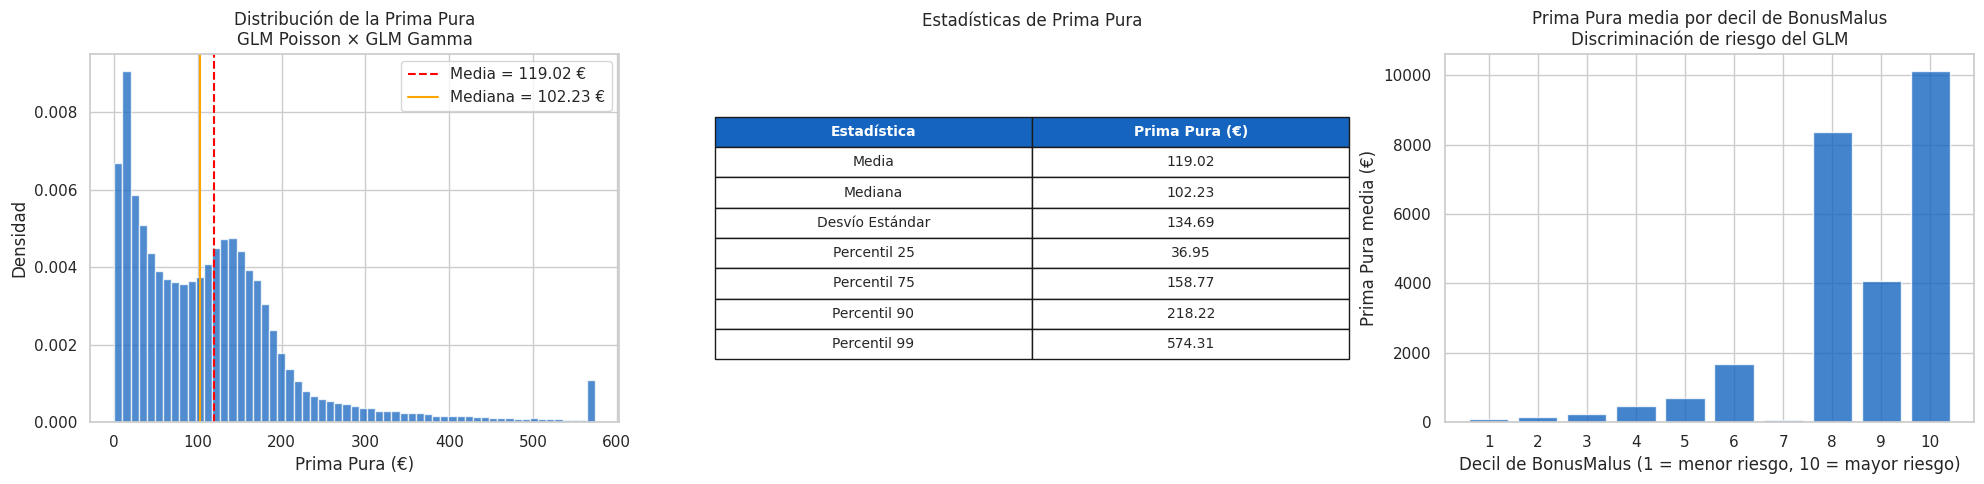

In [61]:
def graficar_prima_pura(prima_df: pd.DataFrame) -> None:
    """
    Visualiza la distribución de la prima pura calculada y sus estadísticas.

    Genera dos paneles:
    1. Histograma de la prima pura (percentil 99 como límite superior).
    2. Tabla de estadísticas descriptivas.
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # ── Panel 1: Distribución de prima pura ───────────────────────────────────
    ax = axes[0]
    cap = prima_df["Prima_Pura"].quantile(0.99)
    bins = np.linspace(0, cap, 60)
    ax.hist(
        prima_df["Prima_Pura"].clip(upper=cap),
        bins=bins, color=PALETA["glm"], alpha=0.75, density=True
    )
    ax.axvline(
        prima_df["Prima_Pura"].mean(),
        color="red", linestyle="--", linewidth=1.5,
        label=f"Media = {prima_df['Prima_Pura'].mean():.2f} €"
    )
    ax.axvline(
        prima_df["Prima_Pura"].median(),
        color="orange", linestyle="-", linewidth=1.5,
        label=f"Mediana = {prima_df['Prima_Pura'].median():.2f} €"
    )
    ax.set_xlabel("Prima Pura (€)")
    ax.set_ylabel("Densidad")
    ax.set_title("Distribución de la Prima Pura\nGLM Poisson × GLM Gamma")
    ax.legend()

    # ── Panel 2: Tabla de estadísticas ────────────────────────────────────────
    ax2 = axes[1]
    ax2.axis("off")

    estadisticas = pd.DataFrame({
        "Estadística": ["Media", "Mediana", "Desvío Estándar",
                         "Percentil 25", "Percentil 75",
                         "Percentil 90", "Percentil 99"],
        "Prima Pura (€)": [
            prima_df["Prima_Pura"].mean(),
            prima_df["Prima_Pura"].median(),
            prima_df["Prima_Pura"].std(),
            prima_df["Prima_Pura"].quantile(0.25),
            prima_df["Prima_Pura"].quantile(0.75),
            prima_df["Prima_Pura"].quantile(0.90),
            prima_df["Prima_Pura"].quantile(0.99),
        ],
    }).round(2)

    tabla = ax2.table(
        cellText=estadisticas.values,
        colLabels=estadisticas.columns,
        loc="center", cellLoc="center"
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)
    tabla.scale(1.2, 1.9)

    for j in range(2):
        tabla[0, j].set_facecolor(PALETA["glm"])
        tabla[0, j].set_text_props(color="white", fontweight="bold")

    ax2.set_title("Estadísticas de Prima Pura", pad=20)

    # ── Panel 3: Prima media por decil de BonusMalus ────────────────────────
    # Muestra cómo el modelo discrimina riesgo a lo largo del predictor
    # más importante. Conecta narrativamente con el Ablation Study:
    # BonusMalus concentra la mayor parte del poder discriminatorio del GLM.
    ax3 = axes[2]

    prima_bm = prima_df.copy()
    prima_bm["BonusMalus"] = freq_raw.loc[split_glm["X_test"].index, "BonusMalus"].values

    # pd.qcut colapsa deciles cuando hay muchos valores repetidos de BonusMalus.
    # Se usan cortes manuales sobre el rango observado para garantizar 10 grupos.
    bm_min = prima_bm["BonusMalus"].min()
    bm_max = prima_bm["BonusMalus"].max()
    cortes_bm = np.linspace(bm_min, bm_max + 0.01, 11)
    prima_bm["decil_BM"] = pd.cut(
        prima_bm["BonusMalus"], bins=cortes_bm, labels=False, include_lowest=True
    )
    resumen_bm = prima_bm.groupby("decil_BM")["Prima_Pura"].mean().reindex(range(10))

    ax3.bar(
        np.arange(1, 11), resumen_bm.values,
        color=PALETA["glm"], alpha=0.8
    )
    ax3.set_xlabel("Decil de BonusMalus (1 = menor riesgo, 10 = mayor riesgo)")
    ax3.set_ylabel("Prima Pura media (€)")
    ax3.set_title("Prima Pura media por decil de BonusMalus\nDiscriminación de riesgo del GLM")
    ax3.set_xticks(range(1, 11))

    plt.tight_layout()
    plt.show()


graficar_prima_pura(prima_df)

## 7. Scoring Comercial — GLM × Score XGBoost

### Concepto

El GLM produce la **prima actuarialmente justa**, correctamente especificada para el proceso generador de los datos. Sin embargo, dentro de un mismo segmento tarifario pueden coexistir pólizas con distintos niveles de riesgo que el GLM no distingue porque no tiene información suficiente en sus predictores.

Un **score de riesgo relativo** construido con XGBoost permite diferenciar esas pólizas:

$$\hat{\text{Prima}}_{\text{final}} = \hat{\text{Prima}}_{\text{GLM}} \times \text{Score}_{\text{ML}}$$

### Propiedades del score

El score se normaliza dividiéndolo por su media en train, de modo que:
- Su **valor esperado es exactamente 1.0** — la prima media de cartera no cambia
- Pólizas con score **> 1** son más riesgosas que el promedio
- Pólizas con score **< 1** son menos riesgosas que el promedio

La **suficiencia de prima** a nivel de cartera queda garantizada por el GLM; el score solo redistribuye el riesgo dentro de ese total.

### Ventaja operativa

| Audiencia | Modelo presentado | Rol |
|---|---|---|
| Regulador / SSN | GLM Poisson + Gamma | Modelo oficial, interpretable, auditable |
| Equipo comercial | Score XGBoost | Segmentación interna, no regulatoria |

In [62]:
def ajustar_xgboost_scoring(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    exposure_train: pd.Series,
    n_estimators: int = 300,
    learning_rate: float = 0.05,
    max_depth: int = 6,
    subsample: float = 0.8,
    colsample_bytree: float = 0.8,
    random_state: int = RANDOM_STATE
) -> XGBRegressor:
    """
    Ajusta un XGBRegressor para construir el score de riesgo relativo.

    Usa sample_weight=Exposure para que pólizas con mayor tiempo de vigencia
    tengan mayor influencia en el entrenamiento — análogo conceptual al offset
    del GLM, aunque menos riguroso estadísticamente.

    Utiliza FEATURES_ML (todas las variables disponibles, incluyendo categóricas
    codificadas) para maximizar la capacidad de discriminación de riesgo.

    Parameters
    ----------
    X_train        : Features ML completas de entrenamiento.
    y_train        : ClaimNb real en train.
    exposure_train : Exposición usada como sample_weight.

    Returns
    -------
    modelo : XGBRegressor ajustado.
    """
    modelo = XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=random_state,
        n_jobs=-1,
        verbosity=0
    )
    modelo.fit(X_train, y_train, sample_weight=exposure_train)
    return modelo


def calcular_score_riesgo(
    xgb_modelo: XGBRegressor,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    preds_glm_test: np.ndarray
) -> tuple:
    """
    Calcula el score de riesgo relativo normalizado y la prima final.

    La normalización divide las predicciones del XGBoost por su media en train,
    garantizando que el score tenga valor esperado 1.0 y que la prima media
    de cartera no se vea alterada respecto al GLM.

    Parameters
    ----------
    xgb_modelo      : XGBoost ajustado para scoring.
    X_train         : Features ML de train (para calcular la media normalizadora).
    X_test          : Features ML de test.
    preds_glm_test  : Prima base del GLM Poisson en test.

    Returns
    -------
    score_test       : Score de riesgo relativo por póliza en test.
    preds_scored     : Prima final = GLM × score.
    media_norm_train : Media usada para normalizar (referencia de cartera).
    """
    raw_train        = xgb_modelo.predict(X_train)
    raw_test         = xgb_modelo.predict(X_test)

    media_norm_train = raw_train.mean()
    score_test       = np.clip(raw_test / media_norm_train, 0, None)
    preds_scored     = preds_glm_test * score_test

    return score_test, preds_scored, media_norm_train


# ── Entrenamiento y scoring ────────────────────────────────────────────────────
xgb_scoring = ajustar_xgboost_scoring(
    X_train        = split_ml["X_train"],
    y_train        = split_ml["y_train"],
    exposure_train = split_ml["exposure_train"]
)

score_test, preds_scored, media_norm = calcular_score_riesgo(
    xgb_modelo     = xgb_scoring,
    X_train        = split_ml["X_train"],
    X_test         = split_ml["X_test"],
    preds_glm_test = preds_glm_poisson
)

print(f"Score — media en test : {score_test.mean():.4f}  (debe ser ≈ 1.0)")
print(f"Score — desvío std    : {score_test.std():.4f}")
print(f"Score — rango         : [{score_test.min():.3f}, {score_test.max():.3f}]")
print()
print(f"Prima GLM media       : {preds_glm_poisson.mean():.6f}")
print(f"Prima Scored media    : {preds_scored.mean():.6f}  (debe ser ≈ Prima GLM)")

Score — media en test : 0.9970  (debe ser ≈ 1.0)
Score — desvío std    : 0.7004
Score — rango         : [0.000, 20.117]

Prima GLM media       : 0.053059
Prima Scored media    : 0.060672  (debe ser ≈ Prima GLM)


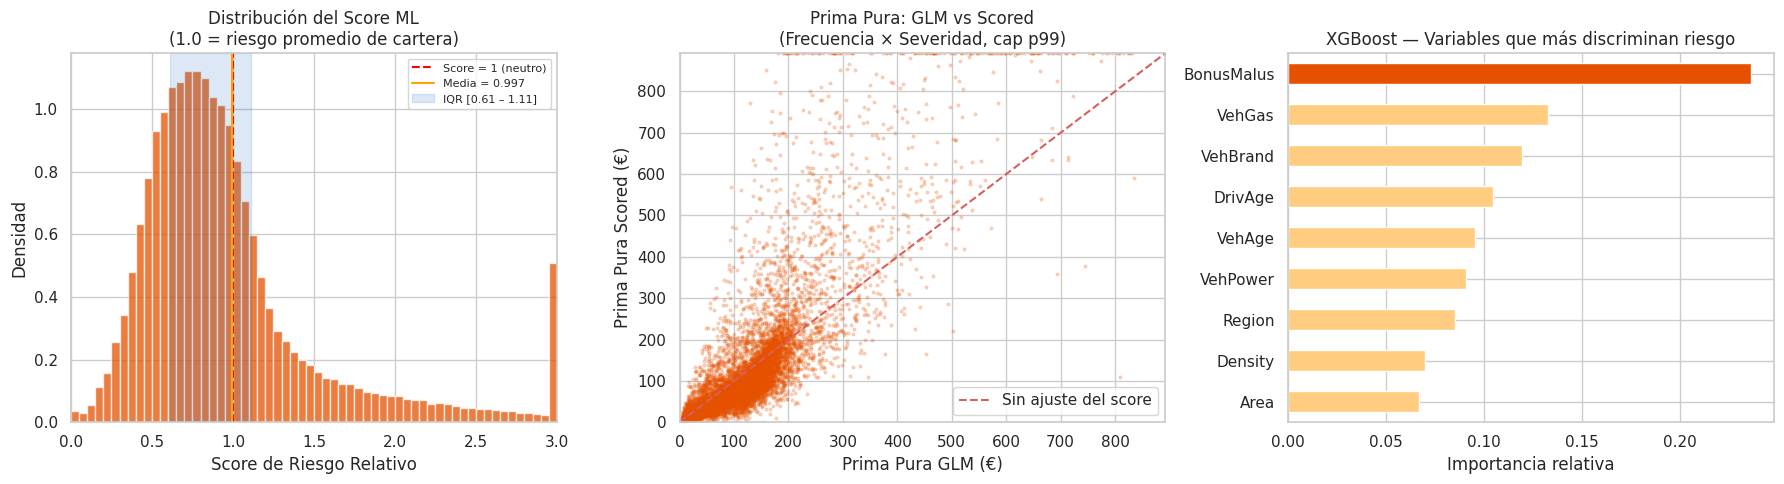

In [63]:
def graficar_scoring(
    score_test: np.ndarray,
    prima_glm_euros: np.ndarray,
    prima_scored_euros: np.ndarray,
    xgb_modelo: XGBRegressor,
    feature_names: list[str]
) -> None:
    """
    Visualiza el análisis del scoring en tres paneles:
    1. Distribución del score de riesgo relativo.
    2. Prima pura GLM vs Prima pura Scored en euros (Frecuencia × Severidad × Score).
    3. Feature importance del XGBoost — qué variables discriminan más riesgo.

    Parameters
    ----------
    score_test         : Score de riesgo relativo por póliza en test.
    prima_glm_euros    : Prima pura GLM en euros (Freq_GLM × Sev_GLM) por póliza.
    prima_scored_euros : Prima pura scored en euros (prima_glm × score) por póliza.
    xgb_modelo         : XGBoost ajustado para scoring.
    feature_names      : Variables usadas en el XGBoost.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ── Panel 1: Distribución del score ───────────────────────────────────────
    ax = axes[0]
    ax.hist(
        np.clip(score_test, 0, 3),
        bins=60, color=PALETA["xgb"], alpha=0.75, density=True
    )
    p25 = np.percentile(score_test, 25)
    p75 = np.percentile(score_test, 75)
    ax.axvline(1.0, color="red", linestyle="--", linewidth=1.5,
               label="Score = 1 (neutro)")
    ax.axvline(score_test.mean(), color="orange", linestyle="-", linewidth=1.5,
               label=f"Media = {score_test.mean():.3f}")
    ax.axvspan(p25, p75, alpha=0.15, color=PALETA["glm"],
               label=f"IQR [{p25:.2f} – {p75:.2f}]")
    ax.set_xlabel("Score de Riesgo Relativo")
    ax.set_ylabel("Densidad")
    ax.set_title("Distribución del Score ML\n(1.0 = riesgo promedio de cartera)")
    ax.set_xlim(0, 3)
    ax.legend(fontsize=8)

    # ── Panel 2: Prima Pura GLM vs Prima Pura Scored (en euros) ──────────────
    # Ambas primas se expresan en euros: Frecuencia × Severidad (× Score para scored).
    # La recta de 45° representa "sin ajuste del score" — prima scored = prima GLM.
    # Puntos por encima: el score elevó la prima (mayor riesgo percibido).
    # Puntos por debajo: el score redujo la prima (menor riesgo percibido).
    ax2 = axes[1]
    cap = float(np.percentile(
        np.concatenate([prima_glm_euros, prima_scored_euros]), 99
    ))
    glm_clip    = np.clip(prima_glm_euros,    0, cap)
    scored_clip = np.clip(prima_scored_euros, 0, cap)

    # Muestra aleatoria de 10.000 pólizas para legibilidad del scatter
    rng = np.random.default_rng(RANDOM_STATE)
    idx_muestra = rng.choice(len(glm_clip), size=min(10_000, len(glm_clip)), replace=False)
    ax2.scatter(glm_clip[idx_muestra], scored_clip[idx_muestra], alpha=0.2, s=4, color=PALETA["xgb"])
    ax2.plot([0, cap], [0, cap], "r--", linewidth=1.5, label="Sin ajuste del score")
    ax2.set_xlim(0, cap)
    ax2.set_ylim(0, cap)
    ax2.set_xlabel("Prima Pura GLM (€)")
    ax2.set_ylabel("Prima Pura Scored (€)")
    ax2.set_title("Prima Pura: GLM vs Scored\n(Frecuencia × Severidad, cap p99)")
    ax2.legend()

    # ── Panel 3: Feature importance XGBoost ───────────────────────────────────
    ax3 = axes[2]
    importancias = pd.Series(
        xgb_modelo.feature_importances_,
        index=feature_names
    ).sort_values()

    colores = [
        PALETA["xgb"] if v >= importancias.max() * 0.8
        else "#FFCC80"
        for v in importancias
    ]
    importancias.plot(kind="barh", ax=ax3, color=colores)
    ax3.set_title("XGBoost — Variables que más discriminan riesgo")
    ax3.set_xlabel("Importancia relativa")

    plt.tight_layout()
    plt.show()


# ── Prima pura GLM en euros para el test set de frecuencia ───────────────────
# Se reutiliza prima_df construida en la Sección 6.
# IMPORTANTE: prima_df está ordenada según split_glm["X_test"].index,
# mientras que score_test sigue el orden de split_ml["X_test"].
# Ambos tienen los mismos índices pero potencialmente en distinto orden,
# por lo que se alinea el score por índice antes de multiplicar.
score_series = pd.Series(score_test, index=split_ml["X_test"].index)
score_alineado = score_series.loc[split_glm["X_test"].index].values

prima_glm_euros    = prima_df["Prima_Pura"].values
prima_scored_euros = prima_glm_euros * score_alineado

graficar_scoring(
    score_test         = score_alineado,
    prima_glm_euros    = prima_glm_euros,
    prima_scored_euros = prima_scored_euros,
    xgb_modelo         = xgb_scoring,
    feature_names      = FEATURES_ML
)

## 8. Ablation Study — Impacto de BonusMalus

### ¿Qué es BonusMalus y por qué importa analizarlo?

`BonusMalus` es el **score actuarial de historial de siniestros** del conductor.
Comienza en 100, disminuye por cada año sin siniestros y aumenta cada vez que el conductor
genera un reclamo. Es el equivalente actuarial al score crediticio en la banca.

**El problema de depender exclusivamente de este dato:**
- Concentra casi todo el poder predictivo en una variable que *resume la variable objetivo*
  (siniestralidad pasada → siniestralidad futura). Las características objetivas del vehículo
  y el conductor aportan señal residual.
- Una aseguradora que ingresa a un mercado nuevo, o que quiere cotizar conductores
  sin historial, no tiene acceso a ese dato.
- En la práctica de insurtechs, construir **proxies de BonusMalus** desde datos
  alternativos (telemetría, comportamiento digital) es exactamente donde el ML agrega
  valor sobre el enfoque clásico.

### Pregunta

> ¿Cuánto poder predictivo perdemos al eliminar BonusMalus?  
> ¿Cambia la conclusión GLM vs XGBoost cuando ambos parten de las mismas features brutas?

### Diseño del experimento

| Configuración | Variables |
|---|---|
| **Con BonusMalus** | VehAge, DrivAge, BonusMalus, VehPower, Density, Area, VehBrand, VehGas, Region |
| **Sin BonusMalus** | VehAge, DrivAge, VehPower, Density, Area, VehBrand, VehGas, Region |

Se reutilizan los mismos índices de train/test para comparabilidad estricta.

In [64]:
# ── Features sin BonusMalus ───────────────────────────────────────────────────
# Sin BonusMalus pero manteniendo el mismo conjunto de variables que el GLM base
FEATURES_GLM_NUM_SIN_BM = ["VehAge", "DrivAge", "VehPower", "Density"]
FEATURES_GLM_CAT_SIN_BM = ["VehGas", "Region"]
FEATURES_GLM_SIN_BM     = FEATURES_GLM_NUM_SIN_BM + FEATURES_GLM_CAT_SIN_BM

FEATURES_ML_SIN_BM   = ["VehAge", "DrivAge", "VehPower", "Density",
                         "Area", "VehBrand", "VehGas", "Region"]

FORMULA_GLM_POISSON_SIN_BM = (
    "ClaimNb ~ VehAge + DrivAge + VehPower + Density "
    "+ C(VehGas) + C(Region)"
)

# ── Splits sin BonusMalus — mismos índices que el split base ──────────────────
split_glm_sin_bm = {
    "X_train"       : freq_raw.loc[split_glm["X_train"].index, FEATURES_GLM_SIN_BM],
    "X_test"        : freq_raw.loc[split_glm["X_test"].index,  FEATURES_GLM_SIN_BM],
    "y_train"       : split_glm["y_train"],
    "y_test"        : split_glm["y_test"],
    "exposure_train": split_glm["exposure_train"],
    "exposure_test" : split_glm["exposure_test"],
}

split_ml_sin_bm = {
    "X_train"       : freq_codificado.loc[split_ml["X_train"].index, FEATURES_ML_SIN_BM],
    "X_test"        : freq_codificado.loc[split_ml["X_test"].index,  FEATURES_ML_SIN_BM],
    "y_train"       : split_ml["y_train"],
    "y_test"        : split_ml["y_test"],
    "exposure_train": split_ml["exposure_train"],
    "exposure_test" : split_ml["exposure_test"],
}

# ── GLM Poisson sin BonusMalus ────────────────────────────────────────────────
print("Entrenando GLM Poisson sin BonusMalus...")
glm_train_sin_bm_df = split_glm_sin_bm["X_train"].copy()
glm_train_sin_bm_df["ClaimNb"] = split_glm_sin_bm["y_train"].values
glm_test_sin_bm_df  = split_glm_sin_bm["X_test"].copy()

glm_sin_bm, preds_glm_sin_bm = ajustar_glm_poisson(
    train_df       = glm_train_sin_bm_df,
    test_df        = glm_test_sin_bm_df,
    formula        = FORMULA_GLM_POISSON_SIN_BM,
    exposure_train = split_glm_sin_bm["exposure_train"],
    exposure_test  = split_glm_sin_bm["exposure_test"]
)

# ── XGBoost sin BonusMalus ────────────────────────────────────────────────────
print("Entrenando XGBoost sin BonusMalus...")
xgb_sin_bm = ajustar_xgboost_scoring(
    X_train        = split_ml_sin_bm["X_train"],
    y_train        = split_ml_sin_bm["y_train"],
    exposure_train = split_ml_sin_bm["exposure_train"]
)
preds_xgb_sin_bm = xgb_sin_bm.predict(split_ml_sin_bm["X_test"])

print("\nModelos sin BonusMalus entrenados.")

Entrenando GLM Poisson sin BonusMalus...
Entrenando XGBoost sin BonusMalus...

Modelos sin BonusMalus entrenados.


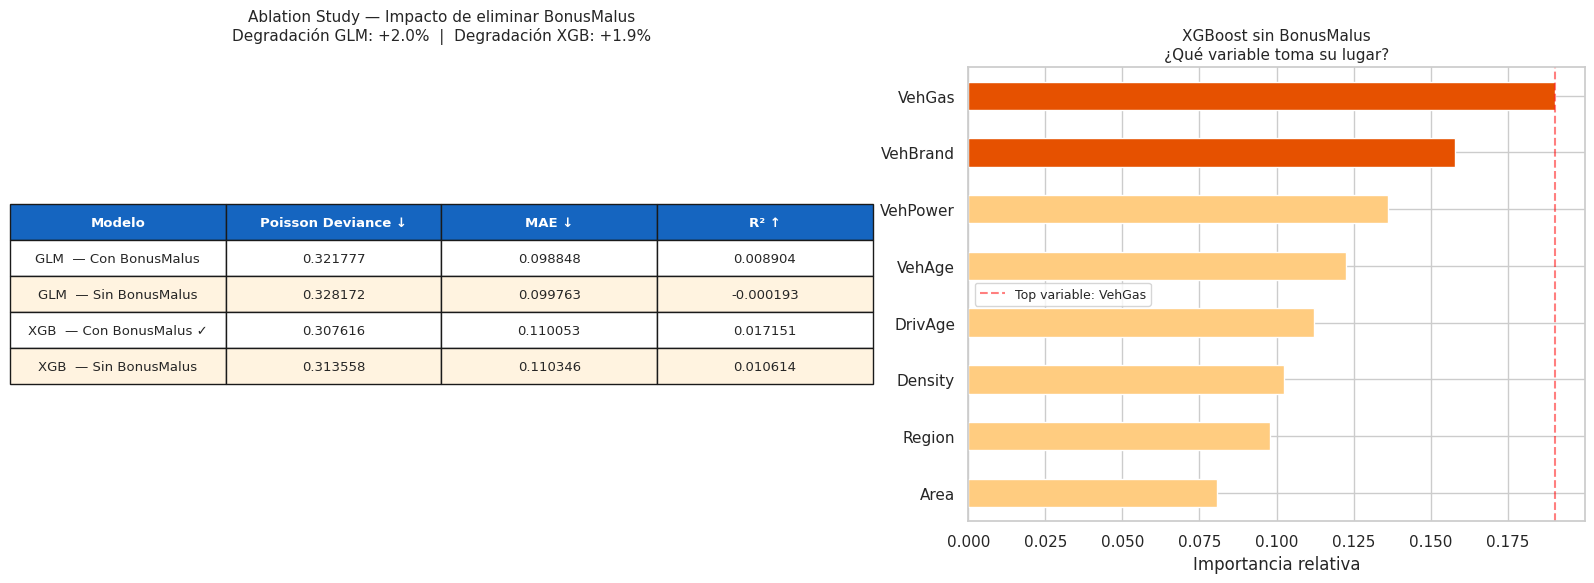


=== Ablation Study — Comparativa completa ===
                       Poisson Deviance       MAE        R²
Modelo                                                     
GLM  — Con BonusMalus          0.321777  0.098848  0.008904
GLM  — Sin BonusMalus          0.328172  0.099763 -0.000193
XGB  — Con BonusMalus          0.307616  0.110053  0.017151
XGB  — Sin BonusMalus          0.313558  0.110346  0.010614

Degradación de Poisson Deviance al eliminar BonusMalus:
  GLM : +1.99%
  XGB : +1.93%

Variable más importante en XGBoost sin BonusMalus: VehGas


In [65]:
def graficar_ablation_study(
    y_test: pd.Series,
    preds_glm_con_bm: np.ndarray,
    preds_glm_sin_bm: np.ndarray,
    preds_xgb_con_bm: np.ndarray,
    preds_xgb_sin_bm: np.ndarray,
    features_sin_bm: list[str],
    xgb_sin_bm_modelo: XGBRegressor
) -> None:
    """
    Visualiza el ablation study en dos paneles:
    1. Tabla comparativa de Poisson Deviance — 4 modelos (con/sin BonusMalus).
    2. Feature importance del XGBoost sin BonusMalus.

    Parameters
    ----------
    y_test              : ClaimNb real en test.
    preds_glm_con_bm    : Predicciones GLM con BonusMalus.
    preds_glm_sin_bm    : Predicciones GLM sin BonusMalus.
    preds_xgb_con_bm    : Predicciones XGBoost con BonusMalus.
    preds_xgb_sin_bm    : Predicciones XGBoost sin BonusMalus.
    features_sin_bm     : Lista de features sin BonusMalus.
    xgb_sin_bm_modelo   : XGBoost sin BonusMalus (para feature importance).
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ── Panel 1: Tabla comparativa ────────────────────────────────────────────
    ax = axes[0]
    ax.axis("off")

    metricas = pd.DataFrame([
        evaluar_modelo_frecuencia("GLM  — Con BonusMalus", y_test, preds_glm_con_bm),
        evaluar_modelo_frecuencia("GLM  — Sin BonusMalus", y_test, preds_glm_sin_bm),
        evaluar_modelo_frecuencia("XGB  — Con BonusMalus", y_test, preds_xgb_con_bm),
        evaluar_modelo_frecuencia("XGB  — Sin BonusMalus", y_test, preds_xgb_sin_bm),
    ]).set_index("Modelo")

    # Degradación relativa al sacar BonusMalus
    dev_glm_base = metricas.loc["GLM  — Con BonusMalus", "Poisson Deviance"]
    dev_xgb_base = metricas.loc["XGB  — Con BonusMalus", "Poisson Deviance"]
    deg_glm = (metricas.loc["GLM  — Sin BonusMalus", "Poisson Deviance"] - dev_glm_base) / dev_glm_base * 100
    deg_xgb = (metricas.loc["XGB  — Sin BonusMalus", "Poisson Deviance"] - dev_xgb_base) / dev_xgb_base * 100

    mejor_dev = metricas["Poisson Deviance"].min()
    filas_tabla = []
    for idx, fila in metricas.iterrows():
        marca = " ✓" if fila["Poisson Deviance"] == mejor_dev else ""
        filas_tabla.append([
            idx + marca,
            f"{fila['Poisson Deviance']:.6f}",
            f"{fila['MAE']:.6f}",
            f"{fila['R²']:.6f}",
        ])

    tabla = ax.table(
        cellText=filas_tabla,
        colLabels=["Modelo", "Poisson Deviance ↓", "MAE ↓", "R² ↑"],
        loc="center", cellLoc="center"
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(9.5)
    tabla.scale(1.4, 2.2)

    for j in range(4):
        tabla[0, j].set_facecolor(PALETA["glm"])
        tabla[0, j].set_text_props(color="white", fontweight="bold")

    # Filas sin BonusMalus con fondo diferenciado
    for i in [2, 4]:
        for j in range(4):
            tabla[i, j].set_facecolor("#FFF3E0")

    ax.set_title(
        f"Ablation Study — Impacto de eliminar BonusMalus\n"
        f"Degradación GLM: +{deg_glm:.1f}%  |  Degradación XGB: +{deg_xgb:.1f}%",
        pad=20, fontsize=11
    )

    # ── Panel 2: Feature importance XGBoost sin BonusMalus ───────────────────
    ax2 = axes[1]
    imp_sin_bm = pd.Series(
        xgb_sin_bm_modelo.feature_importances_,
        index=features_sin_bm
    ).sort_values()

    # Top 2 variables destacadas en naranja oscuro
    top2 = imp_sin_bm.nlargest(2).index
    colores = [
        PALETA["xgb"] if v in top2 else "#FFCC80"
        for v in imp_sin_bm.index
    ]
    imp_sin_bm.plot(kind="barh", ax=ax2, color=colores)
    ax2.set_title(
        f"XGBoost sin BonusMalus\n¿Qué variable toma su lugar?",
        fontsize=11
    )
    ax2.set_xlabel("Importancia relativa")
    ax2.axvline(
        imp_sin_bm.max(), color="red", linestyle="--", alpha=0.5,
        label=f"Top variable: {imp_sin_bm.idxmax()}"
    )
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\n=== Ablation Study — Comparativa completa ===")
    print(metricas.round(6).to_string())
    print(f"\nDegradación de Poisson Deviance al eliminar BonusMalus:")
    print(f"  GLM : +{deg_glm:.2f}%")
    print(f"  XGB : +{deg_xgb:.2f}%")
    print(f"\nVariable más importante en XGBoost sin BonusMalus: {imp_sin_bm.idxmax()}")


graficar_ablation_study(
    y_test             = split_glm["y_test"],
    preds_glm_con_bm   = preds_glm_poisson,
    preds_glm_sin_bm   = preds_glm_sin_bm,
    preds_xgb_con_bm   = xgb_scoring.predict(split_ml["X_test"]),
    preds_xgb_sin_bm   = preds_xgb_sin_bm,
    features_sin_bm    = FEATURES_ML_SIN_BM,
    xgb_sin_bm_modelo  = xgb_sin_bm
)

## 9. Conclusiones

### El modelo GLM es el estándar correcto para este problema

Los GLMs son el estándar de la industria aseguradora para pricing porque:
- El **GLM Poisson** está correctamente especificado para el proceso generador de frecuencia de siniestros — datos de conteo, dispersos, con muchos ceros.
- El **GLM Gamma** es la distribución natural para montos de siniestros — continuos, positivos y con cola derecha.
- El **offset de exposición** permite que las pólizas con distinto tiempo de vigencia sean comparables, algo que los modelos de ML no incorporan de forma nativa.
- Las variables categóricas (`VehGas`, `Region`) se incorporan via dummies con categoría de referencia — el tratamiento estadísticamente correcto para un modelo lineal generalizado.

### El ML agrega valor como capa de scoring, no como reemplazo

La arquitectura **GLM (prima base) + XGBoost (score relativo)** permite:
- Separar el problema actuarial del problema comercial
- Garantizar suficiencia de prima a nivel de cartera (el score tiene media 1.0)
- Presentar un modelo regulatorio interpretable (GLM) y una capa de inteligencia comercial (score)

### BonusMalus concentra la mayor parte del poder predictivo

El ablation study cuantifica cuánto poder predictivo aporta BonusMalus al modelo. La implicancia práctica para insurtechs es concreta: construir proxies de BonusMalus desde datos alternativos (telemetría, comportamiento digital, score crediticio) es exactamente donde el ML genera valor diferencial sobre el enfoque clásico.
